# MorphPT cross-modal transfer — mouse Visium HD results (Random Split)

Aggregates 5-seed × 4-tissue LoRA probing runs with a **random 70/15/15 cell-level split**:
- **Plot 1**: mean test Pearson r per tissue (variance bars across 5 random-split seeds)
- **Plot 2**: tier analysis — test r at top-50, 100, 200, 300, 400, 500 genes
- **Table**: best-performing seed per tissue


## Setup

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT = Path('/hpc/group/jilab/tc459/MorphPT')

plt.rcParams.update({
    'figure.dpi':        110,
    'savefig.dpi':       220,
    'font.size':         10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.titlelocation': 'left',
    'axes.titleweight':  'bold',
    'axes.titlesize':    11,
    'legend.frameon':    False,
})


## Configuration

In [2]:
TISSUES = ['mouse_brain', 'mouse_intestine', 'mouse_kidney', 'mouse_embryo']

# The 5 random seeds used for training (each generates a unique 70/15/15 split)
SEEDS = [23, 123, 456, 789, 1234]
# Tier sizes for the gene-cut analysis
TIERS = [50, 100, 200, 300, 400, 500]

# Training-run metadata (fixed across the 20 jobs)
N_TOP        = 500
SCALES_TAG   = '10.0x'
LOSS_SUFFIX  = 'mse'
SELECT_SEED  = 42      # the --seed default in select_top_genes.py

TISSUE_COLORS = {
    'mouse_brain':     '#4C72B0',
    'mouse_intestine': '#55A868',
    'mouse_kidney':    '#C44E52',
    'mouse_embryo':    '#8172B2',
}

def results_dir(tissue, seed):
    # Random split dirs use 'random' as the split_tag, and base_seed in the suffix
    return PROJECT / 'experiments' / (
        f'lora_probing_{tissue}_top{N_TOP}_multi_random_'
        f'{SCALES_TAG}_{LOSS_SUFFIX}_seed{seed}'
    )

def results_csv(tissue, seed):
    return results_dir(tissue, seed) / 'multi_lora_hybrid_results.csv'

def rank_csv(tissue, seed):
    # Gene selection was still done using the corresponding spatial layout CSV
    layout = f'seed{seed}'
    return (PROJECT / f'cache_{tissue}' / 'splits' / layout /
            f'top{N_TOP}_variance_mincov0.1_train_{layout}_seed{SELECT_SEED}.csv')


## Load results

Loads each (tissue, seed) `multi_lora_hybrid_results.csv` and joins with the
training-set variance rank from the gene-selection CSV. Saves a long-format
combined table for re-use.

In [3]:
rows, missing = [], []

for tissue in TISSUES:
    for seed in SEEDS:
        rcsv = results_csv(tissue, seed)
        kcsv = rank_csv(tissue, seed)

        if not rcsv.exists():
            missing.append((tissue, seed, 'result',  str(rcsv)))
            continue
        if not kcsv.exists():
            missing.append((tissue, seed, 'ranking', str(kcsv)))
            continue

        res   = pd.read_csv(rcsv)
        ranks = pd.read_csv(kcsv)[['gene_idx', 'rank']]
        merged = res.merge(ranks, on='gene_idx', how='left')

        # Single-seed runs label their seed column as test_pearson_s{seed}
        test_col = next(c for c in merged.columns if c.startswith('test_pearson_s'))
        val_col  = next(c for c in merged.columns if c.startswith('val_pearson_s'))

        for _, r in merged.iterrows():
            rows.append({
                'tissue':       tissue,
                'seed':         seed,
                'gene_idx':     int(r['gene_idx']),
                'gene_name':    r['gene_name'],
                'rank':         int(r['rank']) if pd.notna(r['rank']) else None,
                'test_pearson': float(r[test_col]),
                'val_pearson':  float(r[val_col]),
            })

df = pd.DataFrame(rows)
print(f'Loaded: {len(df):,} (gene, tissue, seed) rows from '
      f'{df.groupby(["tissue","seed"]).ngroups} runs')

if missing:
    print(f'\nMissing ({len(missing)}):')
    for m in missing:
        print('  ', *m[:3])

# Save for downstream use
df.to_csv('mouse_multi_seed_results_random.csv', index=False)


Loaded: 10,000 (gene, tissue, seed) rows from 20 runs


## Per-run summary

In [4]:
per_run = (df.groupby(['tissue', 'seed'])
             .agg(mean_test_r   = ('test_pearson', 'mean'),
                  median_test_r = ('test_pearson', 'median'),
                  n_genes       = ('gene_idx',     'count'))
             .reset_index())

# Show as a tissue × seed pivot
pivot = per_run.pivot(index='tissue', columns='seed', values='mean_test_r')
pivot = pivot[SEEDS]   # enforce column order
pivot['mean'] = pivot.mean(axis=1)
pivot['std']  = pivot[SEEDS].std(axis=1)
print('Mean test Pearson r per (tissue × random seed):\n')
print(pivot.round(4))


Mean test Pearson r per (tissue × random seed):

seed                 23     123     456     789    1234    mean     std
tissue                                                                 
mouse_brain      0.3222  0.3178  0.3180  0.3191  0.3205  0.3195  0.0018
mouse_embryo     0.2743  0.2762  0.2774  0.2774  0.2794  0.2769  0.0019
mouse_intestine  0.2823  0.2801  0.2805  0.2807  0.2810  0.2809  0.0008
mouse_kidney     0.3436  0.3379  0.3442  0.3487  0.3488  0.3446  0.0045


## Plot 1 — Mean test r per tissue with seed variance

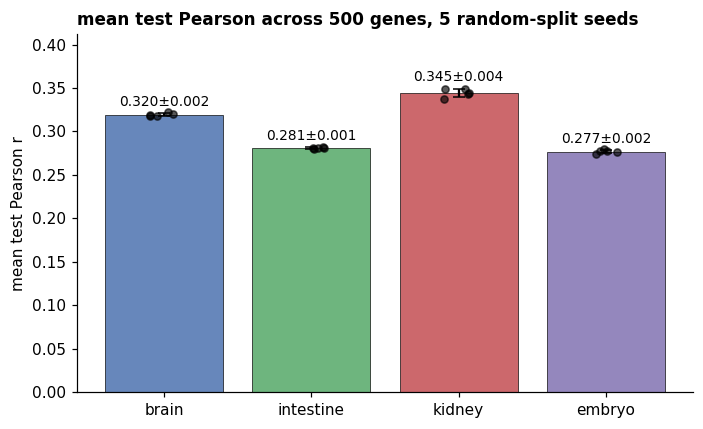

In [5]:
fig, ax = plt.subplots(figsize=(6.5, 4))

# Mean of per-seed-means → bar value; std across seeds → error bar
agg = (per_run.groupby('tissue')['mean_test_r']
              .agg(['mean', 'std', list])
              .reindex(TISSUES))

xs = np.arange(len(agg))
ax.bar(xs, agg['mean'], yerr=agg['std'], capsize=4,
       color=[TISSUE_COLORS[t] for t in agg.index],
       edgecolor='black', linewidth=0.5, alpha=0.85)

# Overlay individual seed points
rng = np.random.default_rng(0)
for i, (_, row) in enumerate(agg.iterrows()):
    seed_means = row['list']
    xj = i + rng.uniform(-0.10, 0.10, len(seed_means))
    ax.scatter(xj, seed_means, s=22, color='black', alpha=0.65, zorder=3)

ax.set_xticks(xs)
ax.set_xticklabels([t.replace('mouse_', '') for t in agg.index])
ax.set_ylabel('mean test Pearson r')
ax.set_title('mean test Pearson across 500 genes, 5 random-split seeds')

# Annotate value above each bar
for i, (mean, std) in enumerate(zip(agg['mean'], agg['std'])):
    ax.text(i, mean + std + 0.005, f'{mean:.3f}±{std:.3f}',
            ha='center', va='bottom', fontsize=9)

ax.set_ylim(0, max(agg['mean'] + agg['std']) * 1.18)
plt.tight_layout()
plt.savefig('plot_mean_test_r_random.pdf', bbox_inches='tight')
plt.show()


## Plot 2 — Tier analysis

For each (tissue, seed), compute the mean test Pearson r over the top-N
most variable genes (ranked by training-set variance in the corresponding
spatial layout). N ranges over the tier sizes. Then average across 5 seeds.

In [6]:
tier_rows = []
for tissue in TISSUES:
    for seed in SEEDS:
        sub = df[(df['tissue'] == tissue) & (df['seed'] == seed)]
        if sub.empty:
            continue
        for tier in TIERS:
            top_n = sub[sub['rank'] <= tier]
            tier_rows.append({
                'tissue':       tissue,
                'seed':         seed,
                'tier':         tier,
                'mean_test_r':  top_n['test_pearson'].mean(),
                'n_genes':      len(top_n),
            })

tier_df = pd.DataFrame(tier_rows)
tier_agg = (tier_df.groupby(['tissue', 'tier'])
                   .agg(mean=('mean_test_r', 'mean'),
                        std =('mean_test_r', 'std'))
                   .reset_index())

print('Tier means (tissue × tier):\n')
print(tier_agg.pivot(index='tier', columns='tissue', values='mean')[TISSUES].round(3))


Tier means (tissue × tier):

tissue  mouse_brain  mouse_intestine  mouse_kidney  mouse_embryo
tier                                                            
50            0.455            0.604         0.640         0.495
100           0.408            0.492         0.550         0.398
200           0.368            0.402         0.460         0.338
300           0.347            0.351         0.411         0.312
400           0.335            0.309         0.375         0.291
500           0.320            0.281         0.345         0.277


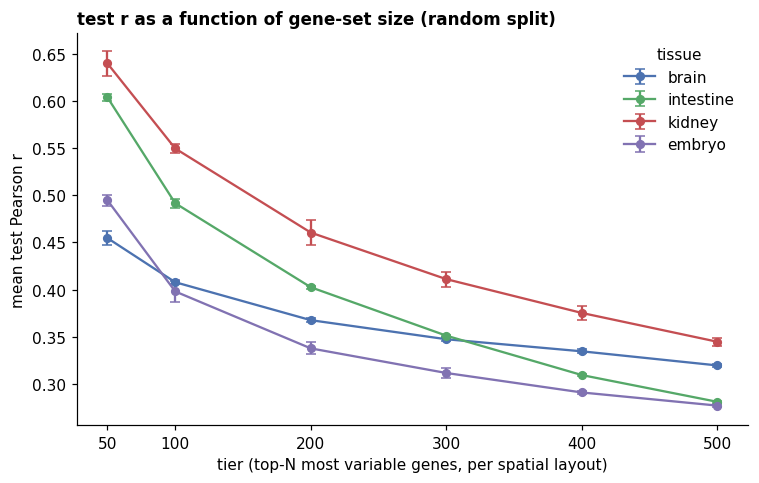

In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for tissue in TISSUES:
    sub = tier_agg[tier_agg['tissue'] == tissue].sort_values('tier')
    ax.errorbar(sub['tier'], sub['mean'], yerr=sub['std'],
                marker='o', markersize=5, capsize=3, linewidth=1.5,
                color=TISSUE_COLORS[tissue],
                label=tissue.replace('mouse_', ''))

ax.set_xlabel('tier (top-N most variable genes, per spatial layout)')
ax.set_ylabel('mean test Pearson r')
ax.set_title('test r as a function of gene-set size (random split)')
ax.set_xticks(TIERS)
ax.legend(loc='upper right', title='tissue')
plt.tight_layout()
plt.savefig('plot_tier_curves_random.pdf', bbox_inches='tight')
plt.show()


## Plot 3 — Tier analysis by test performance

For each (tissue, seed), rank the 500 genes by their **test** Pearson r
and take the top-N. This is a *post-hoc* ranking — useful for showing the
ceiling of per-gene predictability, but circular as a selection rule
(you only know which genes are top-N after evaluating).

The gap between this curve and Plot 2 is the "cost" of using an a-priori
selection rule (variance, no leakage) instead of an oracle ranking.

In [7]:
perf_tier_rows = []
for tissue in TISSUES:
    for seed in SEEDS:
        sub = df[(df['tissue'] == tissue) & (df['seed'] == seed)]
        if sub.empty:
            continue
        sub_sorted = sub.sort_values('test_pearson', ascending=False)
        for tier in TIERS:
            perf_tier_rows.append({
                'tissue':      tissue,
                'seed':        seed,
                'tier':        tier,
                'mean_test_r': sub_sorted.head(tier)['test_pearson'].mean(),
            })

perf_tier_df  = pd.DataFrame(perf_tier_rows)
perf_tier_agg = (perf_tier_df.groupby(['tissue', 'tier'])
                             .agg(mean=('mean_test_r', 'mean'),
                                  std =('mean_test_r', 'std'))
                             .reset_index())

print('Performance-tier means (tissue × tier):\n')
print(perf_tier_agg.pivot(index='tier', columns='tissue',
                          values='mean')[TISSUES].round(3))


Performance-tier means (tissue × tier):

tissue  mouse_brain  mouse_intestine  mouse_kidney  mouse_embryo
tier                                                            
50            0.535            0.695         0.752         0.666
100           0.481            0.593         0.681         0.559
200           0.421            0.463         0.560         0.434
300           0.380            0.382         0.468         0.361
400           0.348            0.327         0.399         0.314
500           0.320            0.281         0.345         0.277


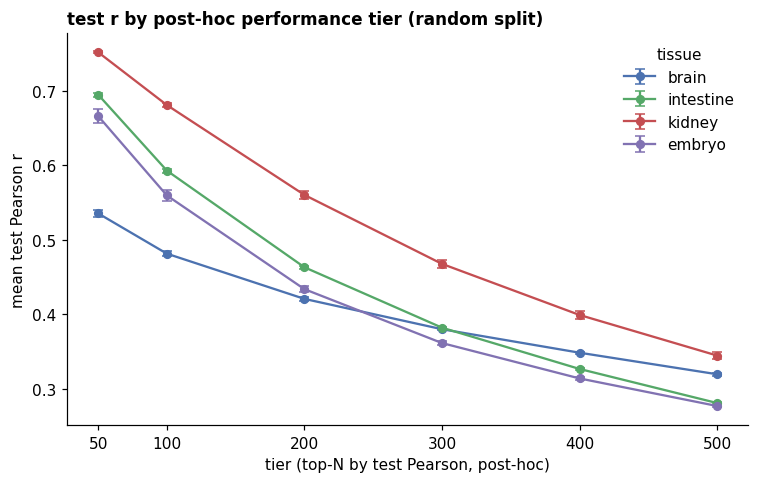

In [9]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for tissue in TISSUES:
    sub = perf_tier_agg[perf_tier_agg['tissue'] == tissue].sort_values('tier')
    ax.errorbar(sub['tier'], sub['mean'], yerr=sub['std'],
                marker='o', markersize=5, capsize=3, linewidth=1.5,
                color=TISSUE_COLORS[tissue],
                label=tissue.replace('mouse_', ''))

ax.set_xlabel('tier (top-N by test Pearson, post-hoc)')
ax.set_ylabel('mean test Pearson r')
ax.set_title('test r by post-hoc performance tier (random split)')
ax.set_xticks(TIERS)
ax.legend(loc='upper right', title='tissue')
plt.tight_layout()
plt.savefig('plot_tier_curves_performance_random.pdf', bbox_inches='tight')
plt.show()


## Plot 4 — Variance-ranked vs performance-ranked tiers (4-panel)

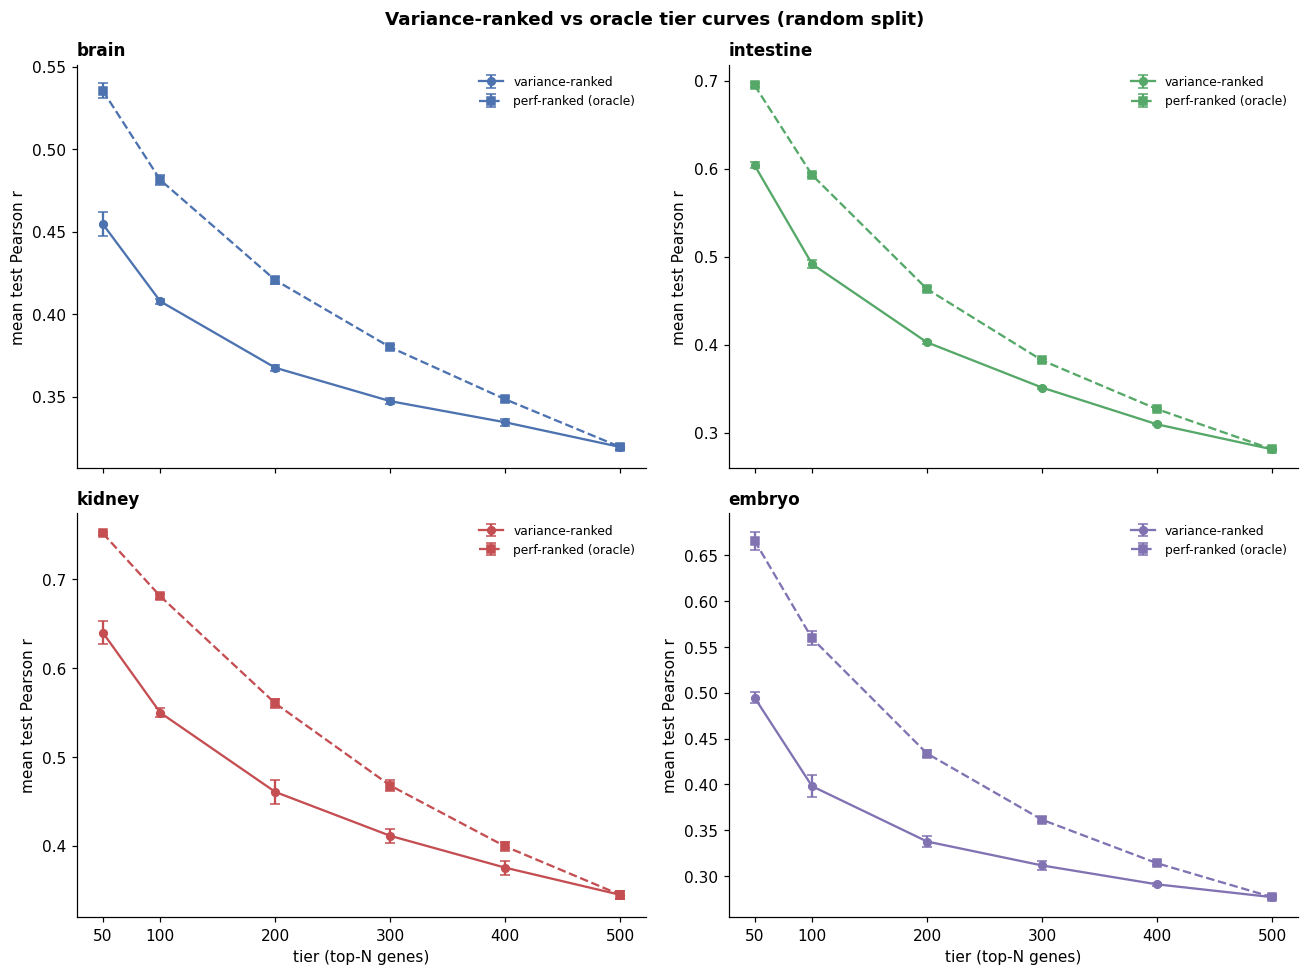

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True, sharey=False)
axes = axes.flatten()

for ax, tissue in zip(axes, TISSUES):
    t_var  = tier_agg[tier_agg['tissue'] == tissue].sort_values('tier')
    t_perf = perf_tier_agg[perf_tier_agg['tissue'] == tissue].sort_values('tier')

    ax.errorbar(t_var['tier'],  t_var['mean'],  yerr=t_var['std'],
                marker='o', markersize=5, capsize=3, linewidth=1.5,
                color=TISSUE_COLORS[tissue], label='variance-ranked')
    ax.errorbar(t_perf['tier'], t_perf['mean'], yerr=t_perf['std'],
                marker='s', markersize=5, capsize=3, linewidth=1.5,
                color=TISSUE_COLORS[tissue], linestyle='--', label='perf-ranked (oracle)')

    ax.set_title(tissue.replace('mouse_', ''))
    ax.set_xticks(TIERS)
    ax.set_ylabel('mean test Pearson r')
    ax.legend(fontsize=8)

for ax in axes[-2:]:
    ax.set_xlabel('tier (top-N genes)')

fig.suptitle('Variance-ranked vs oracle tier curves (random split)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_tier_curves_comparison_random.pdf', bbox_inches='tight')
plt.show()


## Top genes per tissue

In [9]:
per_gene = (df.groupby(['tissue', 'gene_name'])['test_pearson']
              .agg(['mean', 'std', 'count'])
              .reset_index())

for tissue in TISSUES:
    sub = per_gene[per_gene['tissue'] == tissue].sort_values('mean', ascending=False)
    print(f'\n{tissue}: top 10 most predictable genes (mean ± std across 5 seeds)')
    print(sub.head(10)[['gene_name', 'mean', 'std', 'count']].round(3).to_string(index=False))



mouse_brain: top 10 most predictable genes (mean ± std across 5 seeds)
gene_name  mean   std  count
     Nrgn 0.732 0.010      5
  Camk2n1 0.691 0.005      5
     Pcp4 0.684 0.004      5
    Ptk2b 0.679 0.013      5
    Olfm1 0.653 0.005      5
  Slc17a7 0.652 0.007      5
   Snap25 0.620 0.018      5
     Hap1 0.615 0.007      4
     Penk 0.612   NaN      1
    Nptxr 0.612 0.012      5

mouse_intestine: top 10 most predictable genes (mean ± std across 5 seeds)
gene_name  mean   std  count
    Apoa1 0.874 0.002      5
    Anpep 0.860 0.003      5
   Defa21 0.840 0.006      5
    Fabp2 0.833 0.002      5
     Lyz1 0.826 0.005      5
    Reg3b 0.825 0.004      5
 AY761184 0.814 0.005      5
     Ang4 0.813 0.006      5
    Itln1 0.810 0.005      5
    Fabp6 0.799 0.002      5

mouse_kidney: top 10 most predictable genes (mean ± std across 5 seeds)
gene_name  mean   std  count
     Umod 0.870 0.001      5
  Slc34a1 0.863 0.001      5
      Kap 0.855 0.002      5
     Gpx3 0.854 0.001    

## MorphPT vs DINOv3 comparison

Loads matching DINOv3 LoRA random-split runs, aligns them to the MorphPT table by tissue, random seed, and gene, and compares both per-run means and per-gene Pearson r values. The current DINOv3 random-split result set may contain fewer than the five MorphPT seeds; the comparison below uses only shared completed seeds.


In [10]:
import re

DINO_JOB_ID = '47020940'
DINO_LOG_GLOB = PROJECT / 'slurm_logs' / f'dinov3_lora_mouse_{DINO_JOB_ID}_*.out'

DINO_MODEL_NAME = 'DINOv3 ViT-B/16 + LoRA'
MORPHPT_MODEL_NAME = 'MorphPT + LoRA'

def dinov3_results_dir(tissue, seed):
    return PROJECT / 'experiments' / (
        f'dinov3_lora_lora_probing_{tissue}_top{N_TOP}_multi_random_'
        f'{SCALES_TAG}_{LOSS_SUFFIX}_seed{seed}'
    )

def dinov3_results_csv(tissue, seed):
    return dinov3_results_dir(tissue, seed) / 'multi_lora_hybrid_results.csv'

def parse_dinov3_log(path):
    text = path.read_text(errors='replace')
    def grab(pattern, default=None, flags=0):
        m = re.search(pattern, text, flags)
        return m.group(1).strip() if m else default

    return {
        'log_file': str(path),
        'array_task': grab(r'Array Task\s*:\s*(\d+)'),
        'tissue': grab(r'Dataset\s*:\s*(mouse_[a-z]+)'),
        'seed': int(grab(r'Layout\s*:\s*seed(\d+)', '0')),
        'best_val_r_log': float(grab(r'Best Inner Validation Pearson:\s*([-+0-9.]+)', 'nan')),
        'final_test_r_log': float(grab(r'Final Test .*? Pearson:\s*([-+0-9.]+)', 'nan')),
        'train_seconds': float(grab(r'Training Complete in\s*([-+0-9.]+)s', 'nan')),
        'saved_csv': grab(r'Saved LORA independent and averaged seed results to\s*(.*multi_lora_hybrid_results\.csv)'),
    }

# DINOv3 logs are useful for sanity checks and run-time metadata.
dinov3_logs = pd.DataFrame([
    parse_dinov3_log(p) for p in sorted(PROJECT.glob(f'slurm_logs/dinov3_lora_mouse_{DINO_JOB_ID}_*.out'))
])
if not dinov3_logs.empty:
    dinov3_logs = dinov3_logs.sort_values(['tissue', 'seed']).reset_index(drop=True)
    display(dinov3_logs[['tissue', 'seed', 'best_val_r_log', 'final_test_r_log', 'train_seconds', 'log_file']])
else:
    print(f'No DINOv3 logs found for job {DINO_JOB_ID}: {DINO_LOG_GLOB}')



,tissue,seed,best_val_r_log,final_test_r_log,train_seconds,log_file
0,mouse_brain,23,0.3133,0.3171,665.9,/hpc/group/jilab/tc459/MorphPT/slurm_logs/dino...
1,mouse_brain,123,0.3127,0.3123,641.4,/hpc/group/jilab/tc459/MorphPT/slurm_logs/dino...
2,mouse_brain,456,0.3110,0.3127,656.6,/hpc/group/jilab/tc459/MorphPT/slurm_logs/dino...
3,mouse_embryo,23,0.2723,0.2721,4192.1,/hpc/group/jilab/tc459/MorphPT/slurm_logs/dino...
4,mouse_embryo,123,0.2751,0.2738,4161.3,/hpc/group/jilab/tc459/MorphPT/slurm_logs/dino...
5,mouse_embryo,456,0.2763,0.2752,4739.9,/hpc/group/jilab/tc459/MorphPT/slurm_logs/dino...
6,mouse_intestine,23,0.2812,0.2814,1414.5,/hpc/group/jilab/tc459/MorphPT/slurm_logs/dino...
7,mouse_intestine,123,0.2802,0.2795,1471.3,/hpc/group/jilab/tc459/MorphPT/slurm_logs/dino...
8,mouse_intestine,456,0.2793,0.2797,1416.3,/hpc/group/jilab/tc459/MorphPT/slurm_logs/dino...
9,mouse_kidney,23,0.3410,0.3423,3051.9,/hpc/group/jilab/tc459/MorphPT/slurm_logs/dino...


In [11]:
dinov3_rows, dinov3_missing = [], []

for tissue in TISSUES:
    for seed in SEEDS:
        rcsv = dinov3_results_csv(tissue, seed)
        kcsv = rank_csv(tissue, seed)

        if not rcsv.exists():
            dinov3_missing.append((tissue, seed, str(rcsv)))
            continue
        if not kcsv.exists():
            dinov3_missing.append((tissue, seed, str(kcsv)))
            continue

        res = pd.read_csv(rcsv)
        ranks = pd.read_csv(kcsv)[['gene_idx', 'rank']]
        merged = res.merge(ranks, on='gene_idx', how='left')

        test_col = next(c for c in merged.columns if c.startswith('test_pearson_s'))
        val_col = next(c for c in merged.columns if c.startswith('val_pearson_s'))

        for _, r in merged.iterrows():
            dinov3_rows.append({
                'model': DINO_MODEL_NAME,
                'tissue': tissue,
                'seed': seed,
                'gene_idx': int(r['gene_idx']),
                'gene_name': r['gene_name'],
                'rank': int(r['rank']) if pd.notna(r['rank']) else None,
                'test_pearson': float(r[test_col]),
                'val_pearson': float(r[val_col]),
            })

dinov3_df = pd.DataFrame(dinov3_rows)
print(f'Loaded DINOv3: {len(dinov3_df):,} (gene, tissue, seed) rows from '
      f'{dinov3_df.groupby(["tissue", "seed"]).ngroups if not dinov3_df.empty else 0} runs')

if dinov3_missing:
    print(f'\nMissing DINOv3 random-split results ({len(dinov3_missing)}):')
    for tissue, seed, path in dinov3_missing:
        print(f'  {tissue:16s} seed={seed:<4} {path}')

morphpt_df = df.assign(model=MORPHPT_MODEL_NAME)
common_runs = sorted(
    set(map(tuple, morphpt_df[['tissue', 'seed']].drop_duplicates().to_numpy())) &
    set(map(tuple, dinov3_df[['tissue', 'seed']].drop_duplicates().to_numpy()))
)
print(f'\nShared MorphPT/DINOv3 runs used for paired comparison: {len(common_runs)}')
print(common_runs)

dinov3_df.to_csv('dinov3_mouse_multi_seed_results_random.csv', index=False)



Loaded DINOv3: 6,000 (gene, tissue, seed) rows from 12 runs

Missing DINOv3 random-split results (8):
  mouse_brain      seed=789  /hpc/group/jilab/tc459/MorphPT/experiments/dinov3_lora_lora_probing_mouse_brain_top500_multi_random_10.0x_mse_seed789/multi_lora_hybrid_results.csv
  mouse_brain      seed=1234 /hpc/group/jilab/tc459/MorphPT/experiments/dinov3_lora_lora_probing_mouse_brain_top500_multi_random_10.0x_mse_seed1234/multi_lora_hybrid_results.csv
  mouse_intestine  seed=789  /hpc/group/jilab/tc459/MorphPT/experiments/dinov3_lora_lora_probing_mouse_intestine_top500_multi_random_10.0x_mse_seed789/multi_lora_hybrid_results.csv
  mouse_intestine  seed=1234 /hpc/group/jilab/tc459/MorphPT/experiments/dinov3_lora_lora_probing_mouse_intestine_top500_multi_random_10.0x_mse_seed1234/multi_lora_hybrid_results.csv
  mouse_kidney     seed=789  /hpc/group/jilab/tc459/MorphPT/experiments/dinov3_lora_lora_probing_mouse_kidney_top500_multi_random_10.0x_mse_seed789/multi_lora_hybrid_results.csv
  

In [12]:
morphpt_common = morphpt_df.merge(
    pd.DataFrame(common_runs, columns=['tissue', 'seed']),
    on=['tissue', 'seed'],
    how='inner',
)

combined_models = pd.concat([morphpt_common, dinov3_df], ignore_index=True)

paired_gene = morphpt_common.merge(
    dinov3_df,
    on=['tissue', 'seed', 'gene_idx', 'gene_name', 'rank'],
    suffixes=('_morphpt', '_dinov3'),
)
paired_gene['delta_dinov3_minus_morphpt'] = (
    paired_gene['test_pearson_dinov3'] - paired_gene['test_pearson_morphpt']
)

per_run_compare = (paired_gene.groupby(['tissue', 'seed'])
                   .agg(morphpt_mean=('test_pearson_morphpt', 'mean'),
                        dinov3_mean=('test_pearson_dinov3', 'mean'),
                        mean_delta=('delta_dinov3_minus_morphpt', 'mean'),
                        median_delta=('delta_dinov3_minus_morphpt', 'median'),
                        n_genes=('gene_idx', 'count'))
                   .reset_index())

per_tissue_compare = (per_run_compare.groupby('tissue')
                      .agg(morphpt_mean=('morphpt_mean', 'mean'),
                           morphpt_std=('morphpt_mean', 'std'),
                           dinov3_mean=('dinov3_mean', 'mean'),
                           dinov3_std=('dinov3_mean', 'std'),
                           delta_mean=('mean_delta', 'mean'),
                           delta_std=('mean_delta', 'std'),
                           n_runs=('seed', 'count'),
                           n_genes_per_run=('n_genes', 'min'))
                      .reindex(TISSUES)
                      .reset_index())

paired_gene.to_csv('morphpt_vs_dinov3_paired_gene_random.csv', index=False)
per_run_compare.to_csv('morphpt_vs_dinov3_per_run_random.csv', index=False)
per_tissue_compare.to_csv('morphpt_vs_dinov3_per_tissue_random.csv', index=False)

print('Per-run paired mean test Pearson r:')
display(per_run_compare.round(4))

print('Per-tissue paired summary across shared random seeds:')
display(per_tissue_compare.round(4))



Per-run paired mean test Pearson r:


,tissue,seed,morphpt_mean,dinov3_mean,mean_delta,median_delta,n_genes
0,mouse_brain,23,0.3222,0.3171,-0.0051,-0.0048,500
1,mouse_brain,123,0.3178,0.3123,-0.0055,-0.0052,500
2,mouse_brain,456,0.3180,0.3127,-0.0053,-0.0051,500
3,mouse_embryo,23,0.2743,0.2721,-0.0022,-0.0019,500
4,mouse_embryo,123,0.2762,0.2738,-0.0024,-0.0022,500
5,mouse_embryo,456,0.2774,0.2752,-0.0022,-0.0021,500
6,mouse_intestine,23,0.2823,0.2814,-0.0009,-0.0008,500
7,mouse_intestine,123,0.2801,0.2795,-0.0006,-0.0004,500
8,mouse_intestine,456,0.2805,0.2797,-0.0008,-0.0005,500
9,mouse_kidney,23,0.3436,0.3423,-0.0013,-0.0013,500


Per-tissue paired summary across shared random seeds:


,tissue,morphpt_mean,morphpt_std,dinov3_mean,dinov3_std,delta_mean,delta_std,n_runs,n_genes_per_run
0,mouse_brain,0.3194,0.0025,0.3141,0.0027,-0.0053,0.0002,3,500
1,mouse_intestine,0.2810,0.0012,0.2802,0.0010,-0.0008,0.0001,3,500
2,mouse_kidney,0.3419,0.0035,0.3405,0.0039,-0.0014,0.0004,3,500
3,mouse_embryo,0.2760,0.0016,0.2737,0.0016,-0.0023,0.0001,3,500


## Plot 5 — MorphPT vs DINOv3 headline comparison


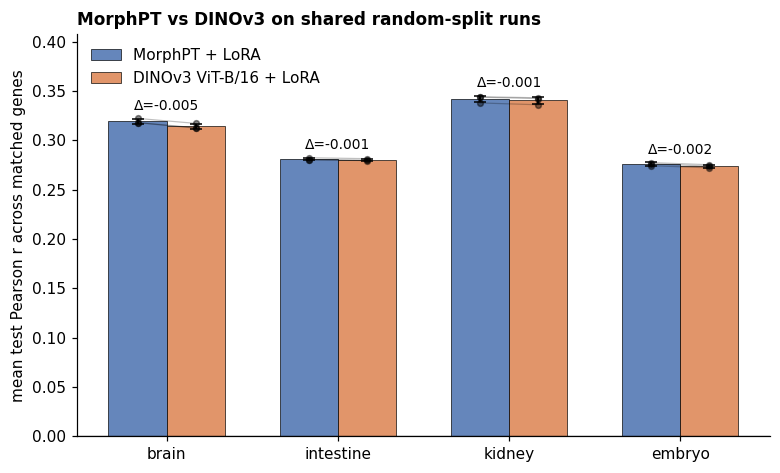

In [13]:
fig, ax = plt.subplots(figsize=(7.2, 4.4))
xs = np.arange(len(TISSUES))
width = 0.34

morph_y = per_tissue_compare['morphpt_mean'].to_numpy()
dino_y = per_tissue_compare['dinov3_mean'].to_numpy()
morph_err = per_tissue_compare['morphpt_std'].fillna(0).to_numpy()
dino_err = per_tissue_compare['dinov3_std'].fillna(0).to_numpy()

ax.bar(xs - width/2, morph_y, width, yerr=morph_err, capsize=4,
       label=MORPHPT_MODEL_NAME, color='#4C72B0', edgecolor='black', linewidth=0.5, alpha=0.86)
ax.bar(xs + width/2, dino_y, width, yerr=dino_err, capsize=4,
       label=DINO_MODEL_NAME, color='#DD8452', edgecolor='black', linewidth=0.5, alpha=0.86)

# Draw paired seed-level connections so the comparison is visibly matched.
for i, tissue in enumerate(TISSUES):
    sub = per_run_compare[per_run_compare['tissue'] == tissue]
    for _, r in sub.iterrows():
        ax.plot([i - width/2, i + width/2], [r['morphpt_mean'], r['dinov3_mean']],
                color='black', alpha=0.25, linewidth=0.8, zorder=3)
        ax.scatter([i - width/2, i + width/2], [r['morphpt_mean'], r['dinov3_mean']],
                   color='black', alpha=0.45, s=14, zorder=4)

for i, r in per_tissue_compare.iterrows():
    top = max(r['morphpt_mean'] + (0 if pd.isna(r['morphpt_std']) else r['morphpt_std']),
              r['dinov3_mean'] + (0 if pd.isna(r['dinov3_std']) else r['dinov3_std']))
    ax.text(i, top + 0.006, f'Δ={r["delta_mean"]:+.3f}', ha='center', va='bottom', fontsize=9)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(xs)
ax.set_xticklabels([t.replace('mouse_', '') for t in TISSUES])
ax.set_ylabel('mean test Pearson r across matched genes')
ax.set_title('MorphPT vs DINOv3 on shared random-split runs')
ax.legend(loc='upper left')
ax.set_ylim(0, max(np.nanmax(morph_y + morph_err), np.nanmax(dino_y + dino_err)) * 1.18)
plt.tight_layout()
plt.savefig('plot_morphpt_vs_dinov3_mean_random.pdf', bbox_inches='tight')
plt.show()



## Plot 6 — Paired run deltas


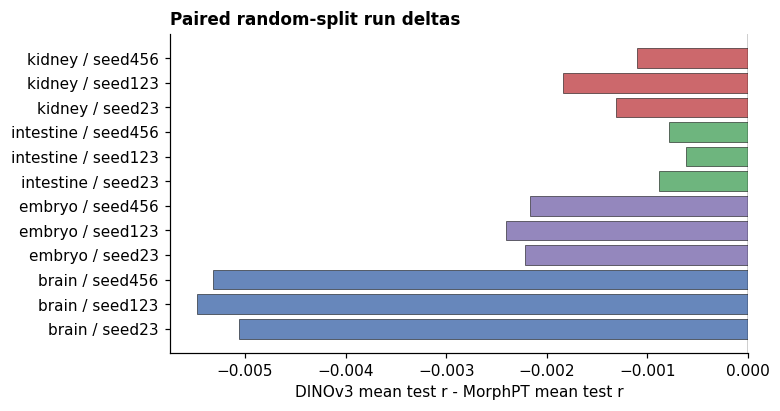

In [14]:
plot_delta = per_run_compare.copy()
plot_delta['label'] = plot_delta['tissue'].str.replace('mouse_', '', regex=False) + ' / seed' + plot_delta['seed'].astype(str)
plot_delta = plot_delta.sort_values(['tissue', 'seed'])

fig, ax = plt.subplots(figsize=(7.2, max(3.5, 0.32 * len(plot_delta))))
colors = [TISSUE_COLORS[t] for t in plot_delta['tissue']]
y = np.arange(len(plot_delta))
ax.barh(y, plot_delta['mean_delta'], color=colors, edgecolor='black', linewidth=0.4, alpha=0.85)
ax.axvline(0, color='black', linewidth=0.9)
ax.set_yticks(y)
ax.set_yticklabels(plot_delta['label'])
ax.set_xlabel('DINOv3 mean test r - MorphPT mean test r')
ax.set_title('Paired random-split run deltas')
plt.tight_layout()
plt.savefig('plot_morphpt_vs_dinov3_run_deltas_random.pdf', bbox_inches='tight')
plt.show()



## Plot 7 — Per-gene agreement


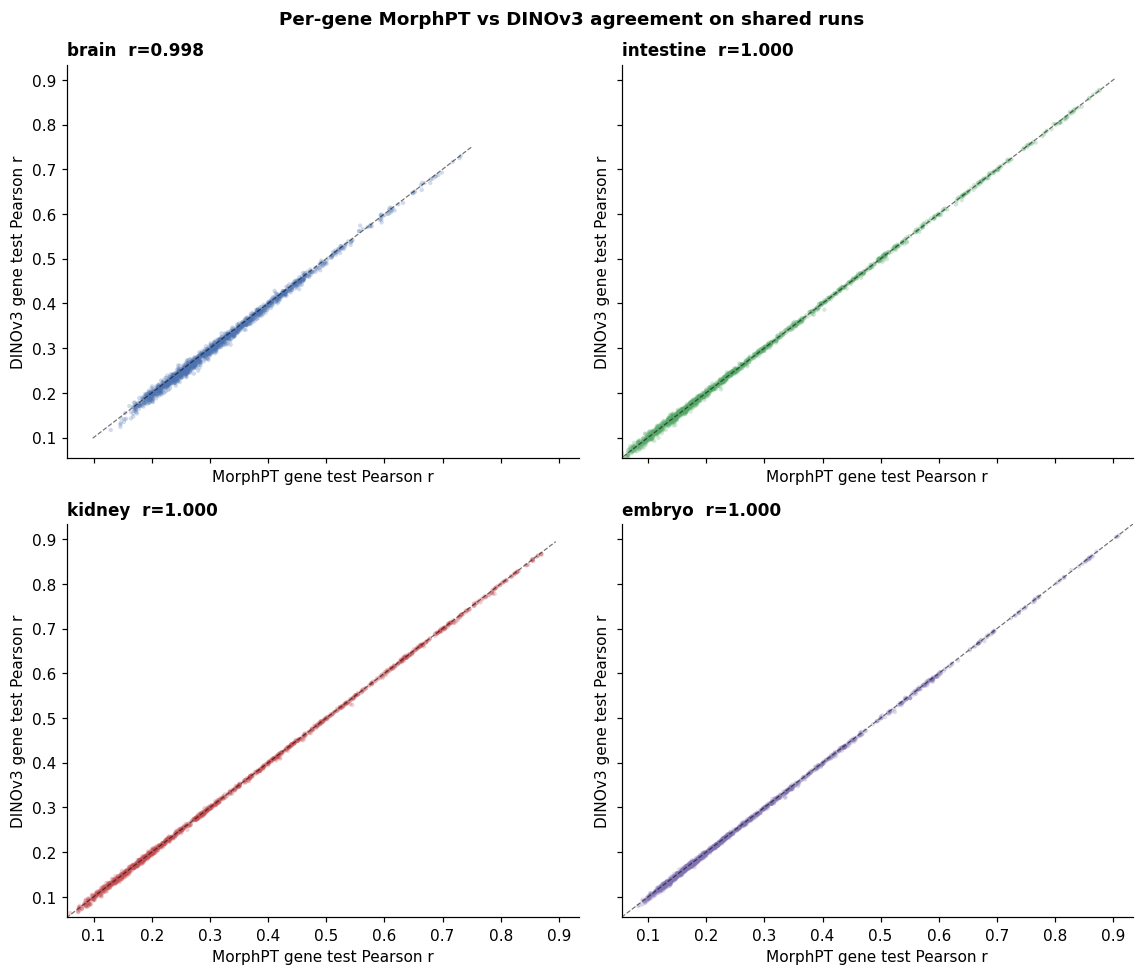

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(10.5, 9), sharex=True, sharey=True)
axes = axes.flatten()

for ax, tissue in zip(axes, TISSUES):
    sub = paired_gene[paired_gene['tissue'] == tissue]
    corr = sub[['test_pearson_morphpt', 'test_pearson_dinov3']].corr().iloc[0, 1]
    ax.scatter(sub['test_pearson_morphpt'], sub['test_pearson_dinov3'],
               s=8, alpha=0.25, color=TISSUE_COLORS[tissue], edgecolors='none')
    lim_min = min(sub['test_pearson_morphpt'].min(), sub['test_pearson_dinov3'].min())
    lim_max = max(sub['test_pearson_morphpt'].max(), sub['test_pearson_dinov3'].max())
    pad = 0.03 * (lim_max - lim_min)
    ax.plot([lim_min - pad, lim_max + pad], [lim_min - pad, lim_max + pad],
            color='black', linestyle='--', linewidth=0.8, alpha=0.55)
    ax.set_title(f'{tissue.replace("mouse_", "")}  r={corr:.3f}')
    ax.set_xlim(lim_min - pad, lim_max + pad)
    ax.set_ylim(lim_min - pad, lim_max + pad)
    ax.set_xlabel('MorphPT gene test Pearson r')
    ax.set_ylabel('DINOv3 gene test Pearson r')

fig.suptitle('Per-gene MorphPT vs DINOv3 agreement on shared runs', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_morphpt_vs_dinov3_gene_scatter_random.pdf', bbox_inches='tight')
plt.show()



## Plot 8 — Variance-ranked tiers, model comparison


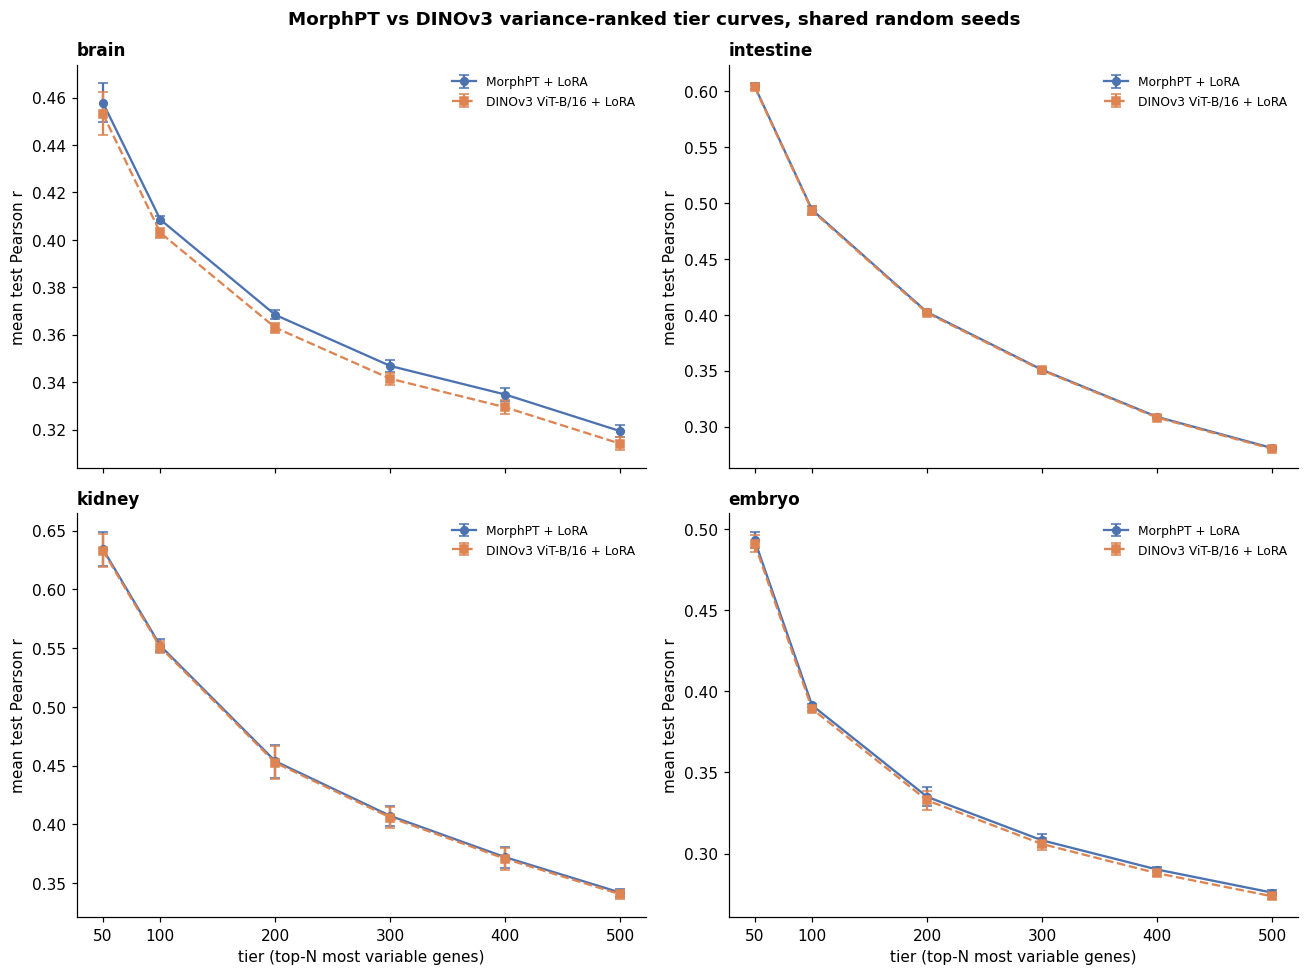

In [16]:
model_tier_rows = []
for model_name, model_df in [(MORPHPT_MODEL_NAME, morphpt_common), (DINO_MODEL_NAME, dinov3_df)]:
    for tissue in TISSUES:
        for seed in sorted(model_df.loc[model_df['tissue'] == tissue, 'seed'].unique()):
            sub = model_df[(model_df['tissue'] == tissue) & (model_df['seed'] == seed)]
            for tier in TIERS:
                top_n = sub[sub['rank'] <= tier]
                model_tier_rows.append({
                    'model': model_name,
                    'tissue': tissue,
                    'seed': seed,
                    'tier': tier,
                    'mean_test_r': top_n['test_pearson'].mean(),
                    'n_genes': len(top_n),
                })

model_tier_df = pd.DataFrame(model_tier_rows)
model_tier_agg = (model_tier_df.groupby(['model', 'tissue', 'tier'])
                  .agg(mean=('mean_test_r', 'mean'),
                       std=('mean_test_r', 'std'))
                  .reset_index())

fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True, sharey=False)
axes = axes.flatten()
model_styles = {
    MORPHPT_MODEL_NAME: dict(marker='o', linestyle='-', color='#4C72B0'),
    DINO_MODEL_NAME: dict(marker='s', linestyle='--', color='#DD8452'),
}

for ax, tissue in zip(axes, TISSUES):
    for model_name, style in model_styles.items():
        sub = model_tier_agg[(model_tier_agg['tissue'] == tissue) &
                             (model_tier_agg['model'] == model_name)].sort_values('tier')
        ax.errorbar(sub['tier'], sub['mean'], yerr=sub['std'], capsize=3,
                    markersize=5, linewidth=1.5, label=model_name, **style)
    ax.set_title(tissue.replace('mouse_', ''))
    ax.set_xticks(TIERS)
    ax.set_ylabel('mean test Pearson r')
    ax.legend(fontsize=8)

for ax in axes[-2:]:
    ax.set_xlabel('tier (top-N most variable genes)')

fig.suptitle('MorphPT vs DINOv3 variance-ranked tier curves, shared random seeds',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_morphpt_vs_dinov3_tier_curves_random.pdf', bbox_inches='tight')
plt.show()



## Files saved

- `mouse_multi_seed_results_random.csv` — MorphPT long-format table (tissue, seed, gene, rank, val_r, test_r)
- `dinov3_mouse_multi_seed_results_random.csv` — DINOv3 long-format table for completed matching random-split runs
- `morphpt_vs_dinov3_paired_gene_random.csv` — paired MorphPT/DINOv3 per-gene table on shared runs
- `morphpt_vs_dinov3_per_run_random.csv` — paired per-run mean comparison
- `morphpt_vs_dinov3_per_tissue_random.csv` — paired per-tissue summary across shared seeds
- `plot_mean_test_r_random.pdf` — MorphPT headline variance-bar plot
- `plot_tier_curves_random.pdf` — MorphPT variance-ranked tier curves
- `plot_tier_curves_performance_random.pdf` — MorphPT performance-ranked tier curves
- `plot_tier_curves_comparison_random.pdf` — MorphPT 4-panel variance vs performance per tissue
- `plot_morphpt_vs_dinov3_mean_random.pdf` — MorphPT vs DINOv3 grouped headline comparison
- `plot_morphpt_vs_dinov3_run_deltas_random.pdf` — paired DINOv3-minus-MorphPT run deltas
- `plot_morphpt_vs_dinov3_gene_scatter_random.pdf` — per-gene agreement scatter panels
- `plot_morphpt_vs_dinov3_tier_curves_random.pdf` — model comparison across variance-ranked gene tiers
